# Content Representation & Similarity
## Module 1: TF-IDF — From Words to Vectors


**How do we turn a bag of words into a number that captures what a song is *about*?** 

**Goal:** In this notebook, we build TF-IDF from scratch, one step at a time, then apply it to 25,000 real song lyrics.


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter
import math
import os

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH        = "../data/spotify/songs_with_attributes_and_lyrics.csv"
SAMPLE_DATA_PATH = "../data/spotify/spotify_sample.parquet"
N_SAMPLE       = 25_000
COL_TRACK_NAME = "name"
COL_ARTIST     = "artists"
COL_LYRICS     = "lyrics"
AUDIO_COLS     = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]

---
## Part A: Building TF-IDF by Hand

We start with a tiny toy corpus — 4 short "songs" — so every computation is visible.

In [4]:
# Our toy corpus: 4 short songs (simplified)
corpus = [
    "love love love baby",
    "dance all night long",
    "love dance move feel",
    "baby baby cry alone",
]
doc_names = ["Song A", "Song B", "Song C", "Song D"]

print("Toy corpus:")
for name, doc in zip(doc_names, corpus):
    print(f"  {name}: '{doc}'")

Toy corpus:
  Song A: 'love love love baby'
  Song B: 'dance all night long'
  Song C: 'love dance move feel'
  Song D: 'baby baby cry alone'


### Step 1: One-Hot Encoding

The simplest representation: **each unique word gets a dimension**.
A document is a binary vector — 1 if the word appears, 0 if not.

**Problem:** loses word count information entirely.

In [5]:
# Build vocabulary (sorted for reproducibility)
all_words = sorted(set(w for doc in corpus for w in doc.split()))
vocab = {word: i for i, word in enumerate(all_words)}

print(f"Vocabulary ({len(vocab)} words): {list(vocab.keys())}")
print()

# One-hot matrix: 1 if word appears in doc, else 0
onehot = np.zeros((len(corpus), len(vocab)), dtype=int)
for i, doc in enumerate(corpus):
    for word in doc.split():
        onehot[i, vocab[word]] = 1

df_onehot = pd.DataFrame(onehot, index=doc_names, columns=vocab.keys())
print("One-Hot Encoding matrix (1 = word present, 0 = absent):")
print(df_onehot.to_string())

Vocabulary (10 words): ['all', 'alone', 'baby', 'cry', 'dance', 'feel', 'long', 'love', 'move', 'night']

One-Hot Encoding matrix (1 = word present, 0 = absent):
        all  alone  baby  cry  dance  feel  long  love  move  night
Song A    0      0     1    0      0     0     0     1     0      0
Song B    1      0     0    0      1     0     1     0     0      1
Song C    0      0     0    0      1     1     0     1     1      0
Song D    0      1     1    1      0     0     0     0     0      0


> **Limitation:** Song A has "love" three times — the one-hot vector treats it the same as Song C which has "love" once.
> We're throwing away frequency information.

### Step 2: Bag-of-Words (Count Matrix)

Instead of 0/1, count how many times each word appears.
This preserves frequency — "love" repeated 3× matters more than "love" once.

In [6]:
# Count matrix: how many times does each word appear in each doc?
bow = np.zeros((len(corpus), len(vocab)), dtype=int)
for i, doc in enumerate(corpus):
    counts = Counter(doc.split())
    for word, count in counts.items():
        bow[i, vocab[word]] = count

df_bow = pd.DataFrame(bow, index=doc_names, columns=vocab.keys())
print("Bag-of-Words (raw counts):")
print(df_bow.to_string())
print()
print("Notice: 'love' appears 3× in Song A, 1× in Song C — now captured.")

Bag-of-Words (raw counts):
        all  alone  baby  cry  dance  feel  long  love  move  night
Song A    0      0     1    0      0     0     0     3     0      0
Song B    1      0     0    0      1     0     1     0     0      1
Song C    0      0     0    0      1     1     0     1     1      0
Song D    0      1     2    1      0     0     0     0     0      0

Notice: 'love' appears 3× in Song A, 1× in Song C — now captured.


### Step 3: Term Frequency (TF)

Raw counts are biased by document length: a 500-word song and a 50-word song
that both use "love" 10× aren't equally "love-heavy."

**Term Frequency** normalizes by document length:
$$\text{TF}(t, d) = \frac{\text{count}(t, d)}{\text{total words in } d}$$

In [7]:
doc_lengths = bow.sum(axis=1, keepdims=True)   # total words per doc
tf = bow / doc_lengths                          # normalize each row

df_tf = pd.DataFrame(tf.round(3), index=doc_names, columns=vocab.keys())
print("Term Frequency (TF) — normalized by document length:")
print(df_tf.to_string())
print()
print("Interpretation: in Song A, 'love' accounts for", round(tf[0, vocab['love']], 3),
      "of all word occurrences (3 out of", doc_lengths[0,0], "words)")

Term Frequency (TF) — normalized by document length:
         all  alone  baby   cry  dance  feel  long  love  move  night
Song A  0.00   0.00  0.25  0.00   0.00  0.00  0.00  0.75  0.00   0.00
Song B  0.25   0.00  0.00  0.00   0.25  0.00  0.25  0.00  0.00   0.25
Song C  0.00   0.00  0.00  0.00   0.25  0.25  0.00  0.25  0.25   0.00
Song D  0.00   0.25  0.50  0.25   0.00  0.00  0.00  0.00  0.00   0.00

Interpretation: in Song A, 'love' accounts for 0.75 of all word occurrences (3 out of 4 words)


### Step 4: Document Frequency (DF) and IDF

**Problem with TF alone:** common words like "love", "baby" appear in many songs.
They have high TF everywhere, so they don't help distinguish songs.

**Solution:** downweight words that appear in many documents.

$$\text{DF}(t) = \text{number of documents containing } t$$
$$\text{IDF}(t) = \log\left(\frac{N}{\text{DF}(t)}\right)$$

- Rare words (appear in 1 doc) → high IDF → kept
- Common words (appear in all docs) → IDF near 0 → suppressed

In [8]:
N = len(corpus)

# DF: how many documents contain each word?
df_count = (bow > 0).sum(axis=0)   # shape: (vocab_size,)
idf = np.log(N / df_count)          # log(N / df)

print(f"N (total documents) = {N}")
print()
print(f"{'Word':<15} {'DF':>5}  {'IDF':>8}  {'Interpretation'}")
print("-" * 55)
for word, idx in vocab.items():
    interp = "rare → high weight" if idf[idx] > 0.5 else "common → low weight"
    print(f"{word:<15} {df_count[idx]:>5}  {idf[idx]:>8.3f}  {interp}")

N (total documents) = 4

Word               DF       IDF  Interpretation
-------------------------------------------------------
all                 1     1.386  rare → high weight
alone               1     1.386  rare → high weight
baby                2     0.693  rare → high weight
cry                 1     1.386  rare → high weight
dance               2     0.693  rare → high weight
feel                1     1.386  rare → high weight
long                1     1.386  rare → high weight
love                2     0.693  rare → high weight
move                1     1.386  rare → high weight
night               1     1.386  rare → high weight


### Step 5: TF-IDF = TF × IDF

Multiply term frequency by inverse document frequency:
$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)$$

Words that are **frequent in this doc** AND **rare across docs** get the highest scores.

In [9]:
tfidf = tf * idf   # broadcast: each row × idf vector

df_tfidf = pd.DataFrame(tfidf.round(4), index=doc_names, columns=vocab.keys())
print("TF-IDF matrix:")
print(df_tfidf.to_string())
print()

# Top word per song
print("Top TF-IDF word per song:")
for i, name in enumerate(doc_names):
    top_word = list(vocab.keys())[np.argmax(tfidf[i])]
    top_score = tfidf[i].max()
    print(f"  {name}: '{top_word}' (score={top_score:.4f})")

TF-IDF matrix:
           all   alone    baby     cry   dance    feel    long    love    move   night
Song A  0.0000  0.0000  0.1733  0.0000  0.0000  0.0000  0.0000  0.5199  0.0000  0.0000
Song B  0.3466  0.0000  0.0000  0.0000  0.1733  0.0000  0.3466  0.0000  0.0000  0.3466
Song C  0.0000  0.0000  0.0000  0.0000  0.1733  0.3466  0.0000  0.1733  0.3466  0.0000
Song D  0.0000  0.3466  0.3466  0.3466  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000

Top TF-IDF word per song:
  Song A: 'love' (score=0.5199)
  Song B: 'all' (score=0.3466)
  Song C: 'feel' (score=0.3466)
  Song D: 'alone' (score=0.3466)


> **Intuition check:**
> - Song B's top word should be unique to it ("night", "long") — neither appear in other songs → IDF is highest.
> - "love" appears in 3 of 4 songs → lower IDF → demoted even if frequent.

### Step 6: Cosine Similarity

TF-IDF vectors live in high-dimensional space. We measure similarity by the **angle** between vectors.

$$\text{cosine}(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$$

- Score = 1.0 → identical direction (same thematic fingerprint)
- Score = 0.0 → orthogonal (no shared vocabulary)

Cosine Similarity matrix:
        Song A  Song B  Song C  Song D
Song A   1.000   0.000   0.300   0.183
Song B   0.000   1.000   0.088   0.000
Song C   0.300   0.088   1.000   0.000
Song D   0.183   0.000   0.000   1.000



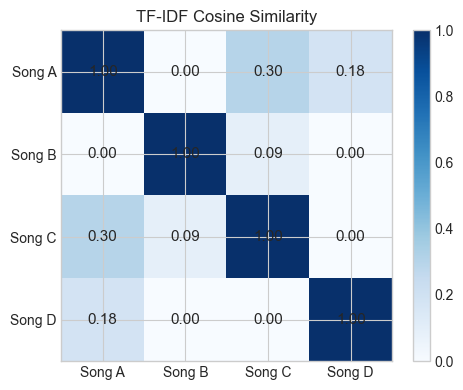

Most similar pair: Song A ↔ Song C (score=0.300)


In [10]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(tfidf)
df_sim = pd.DataFrame(sim.round(3), index=doc_names, columns=doc_names)

print("Cosine Similarity matrix:")
print(df_sim.to_string())
print()

# Visualize
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(doc_names)))
ax.set_xticklabels(doc_names)
ax.set_yticks(range(len(doc_names)))
ax.set_yticklabels(doc_names)
for i in range(len(doc_names)):
    for j in range(len(doc_names)):
        ax.text(j, i, f"{sim[i,j]:.2f}", ha="center", va="center", fontsize=11)
plt.colorbar(im, ax=ax)
ax.set_title("TF-IDF Cosine Similarity")
plt.tight_layout()
plt.show()

print("Most similar pair:", end=" ")
np.fill_diagonal(sim, 0)
i, j = np.unravel_index(sim.argmax(), sim.shape)
print(f"{doc_names[i]} ↔ {doc_names[j]} (score={sim[i,j]:.3f})")

---
## Part B: Applying TF-IDF to Real Spotify Lyrics

Now we scale up to 25,000 real songs using `sklearn.TfidfVectorizer`.

In [11]:
## LOAD SAMPLED DATASET IF AVAILABLE 

if os.path.exists(SAMPLE_DATA_PATH):
    df = pd.read_parquet(SAMPLE_DATA_PATH)
    print(f"Loaded sampled dataset with {len(df):,} songs.")
else:
    print("No sampled dataset found. Sample from original dataset")

    KEY_NOTE_MAP = {
        "C": 0, "C#": 1, "Db": 1, "D": 2, "D#": 3, "Eb": 3,
        "E": 4, "F": 5, "F#": 6, "Gb": 6, "G": 7,
        "G#": 8, "Ab": 8, "A": 9, "A#": 10, "Bb": 10, "B": 11,
    }
    def parse_key(v):
        try: return int(float(v))
        except: return KEY_NOTE_MAP.get(str(v).strip(), -1)
    def parse_mode(v):
        s = str(v).strip().lower()
        if s in ("major", "maj"): return 1
        if s in ("minor", "min"): return 0
        try: return int(float(s))
        except: return -1

    df_raw = pd.read_csv(DATA_PATH, low_memory=False)
    df_raw["key_clean"]  = df_raw["key"].apply(parse_key)
    df_raw["mode_clean"] = df_raw["mode"].apply(parse_mode)
    df_raw["wc"] = df_raw[COL_LYRICS].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

    eligible = df_raw[
        (df_raw["wc"] >= 50)
        & df_raw[AUDIO_COLS].notna().all(axis=1)
        & df_raw["key_clean"].between(0, 11)
        & df_raw["mode_clean"].isin([0, 1])
    ].reset_index(drop=True)

    df = eligible.sample(n=min(N_SAMPLE, len(eligible)), random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Working sample: {len(df):,} songs")

Loaded sampled dataset with 25,000 songs.


In [12]:
def clean_lyrics(text):
    if pd.isna(text) or str(text).strip() == "": return ""
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)       # [Chorus], [Verse 1]
    text = re.sub(r'[^a-z\s]', ' ', text)     # punctuation → space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["lyrics_clean"] = df[COL_LYRICS].apply(clean_lyrics)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

lyrics_vectorizer = TfidfVectorizer(
    max_features=10_000,    # keep top 10k words by frequency
    min_df=5,               # ignore words in fewer than 5 songs
    max_df=0.85,            # ignore words in more than 85% of songs (stopwords)
    sublinear_tf=True,      # use log(1 + tf) to dampen very high counts
)
lyrics_tfidf = lyrics_vectorizer.fit_transform(df["lyrics_clean"])
lyrics_vocab  = lyrics_vectorizer.get_feature_names_out()

print(f"Lyrics TF-IDF matrix: {lyrics_tfidf.shape}")
print(f"  rows    = songs ({lyrics_tfidf.shape[0]:,})")
print(f"  columns = vocabulary terms ({lyrics_tfidf.shape[1]:,})")
print(f"  density = {lyrics_tfidf.nnz / (lyrics_tfidf.shape[0] * lyrics_tfidf.shape[1]):.4%} (very sparse!)")

Lyrics TF-IDF matrix: (25000, 10000)
  rows    = songs (25,000)
  columns = vocabulary terms (10,000)
  density = 0.7968% (very sparse!)


In [14]:
def top_tfidf_words(song_name, df, tfidf_matrix, vocab, col=COL_TRACK_NAME, n=10):
    """Print the top-n TF-IDF words for a song, with scores."""
    idx = df[df[col].str.contains(song_name, case=False, na=False)].index
    if len(idx) == 0:
        print(f"'{song_name}' not found"); return
    row = tfidf_matrix[idx[0]].toarray().flatten()
    top_idx = row.argsort()[::-1][:n]
    print(f"Top-{n} TF-IDF words for: \"{df.loc[idx[0], col]}\" by {df.loc[idx[0], COL_ARTIST]}")
    print(f"  {'Word':<20} {'TF-IDF score':>12}")
    print("  " + "-" * 34)
    for i in top_idx:
        print(f"  {vocab[i]:<20} {row[i]:>12.4f}")

# Try a few songs
for query in ["love", "dance", "night"]:
    top_tfidf_words(query, df, lyrics_tfidf, lyrics_vocab)
    print()

Top-10 TF-IDF words for: "It Was Love" by ZICO
  Word                 TF-IDF score
  ----------------------------------
  whoa                       1.0000
  zwischen                   0.0000
  forbidden                  0.0000
  for                        0.0000
  footsteps                  0.0000
  footprints                 0.0000
  football                   0.0000
  foot                       0.0000
  fools                      0.0000
  foolish                    0.0000

Top-10 TF-IDF words for: "Save The Last Dance For Me" by Harry Connick, Jr.
  Word                 TF-IDF score
  ----------------------------------
  darlin                     0.2731
  whose                      0.2596
  dance                      0.2444
  takin                      0.2385
  save                       0.2200
  asks                       0.2175
  arms                       0.1839
  last                       0.1738
  forget                     0.1719
  home                       0.1612

Top-10 TF

> **Interpretation:** The top TF-IDF words for each song are its *thematic fingerprint* —
> words that appear often in *this* song but not commonly across all 25,000.
> Generic words like "you", "the", "and" are suppressed by the high IDF penalty.

### Finding Similar Songs by Lyrics

In [15]:
from sklearn.neighbors import NearestNeighbors

# Fit kNN on lyrics TF-IDF (cosine metric)
knn_lyrics = NearestNeighbors(n_neighbors=6, metric="cosine", algorithm="brute")
knn_lyrics.fit(lyrics_tfidf)

def find_similar_lyrics(song_name, df, tfidf_matrix, knn_model, n=5):
    """Return top-n most similar songs by lyrics TF-IDF cosine similarity."""
    idx = df[df[COL_TRACK_NAME].str.contains(song_name, case=False, na=False)].index
    if len(idx) == 0:
        print(f"'{song_name}' not found"); return
    query_idx = idx[0]
    query_vec = tfidf_matrix[query_idx]
    distances, neighbors = knn_model.kneighbors(query_vec, n_neighbors=n+1)
    distances, neighbors = distances[0][1:], neighbors[0][1:]  # skip self
    print(f"Songs most similar to: \"{df.loc[query_idx, COL_TRACK_NAME]}\" by {df.loc[query_idx, COL_ARTIST]}")
    print(f"  {'#':<4} {'Song':<40} {'Artist':<25} {'Similarity':>10}")
    print("  " + "-" * 85)
    for rank, (dist, nidx) in enumerate(zip(distances, neighbors), 1):
        sim = 1 - dist
        song = df.loc[nidx, COL_TRACK_NAME][:38]
        artist = df.loc[nidx, COL_ARTIST][:23]
        print(f"  {rank:<4} {song:<40} {artist:<25} {sim:>10.4f}")

for query in ["love", "dance", "night"]:
    find_similar_lyrics(query, df, lyrics_tfidf, knn_lyrics)
    print()

Songs most similar to: "It Was Love" by ZICO
  #    Song                                     Artist                    Similarity
  -------------------------------------------------------------------------------------
  1    正解 - 18FES ver.                          RADWIMPS                      1.0000
  2    Laijaw Malai                             Tribal Rain                   1.0000
  3    It Was Love                              ZICO                          1.0000
  4    Youshi Tanrei Na Uso                     THE ORAL CIGARETTES           1.0000
  5    Phir Kabhi (From "M.S.Dhoni - The Unto   Arijit Singh                  1.0000

Songs most similar to: "Save The Last Dance For Me" by Harry Connick, Jr.
  #    Song                                     Artist                    Similarity
  -------------------------------------------------------------------------------------
  1    Save Your Heart For Me                   Gary Lewis & The Playbo       0.3186
  2    Hold Tight       

---
## Summary

| Representation | What it captures | Key hyperparameters |
|---|---|---|
| One-hot | Word presence (binary) | vocabulary size |
| Bag-of-words | Word counts (raw) | vocabulary size |
| TF-IDF | Word importance (frequency × rarity) | `max_features`, `min_df`, `max_df`, `sublinear_tf` |

**When TF-IDF works well:**
- Documents differ in vocabulary (songs about different topics)
- You want interpretable features (each dimension = a word)

**When TF-IDF struggles:**
- Synonyms ("love" ≠ "affection" in TF-IDF space)
- Short documents (< 20 words → noisy TF estimates)

→ **Module 3** introduces Word2Vec, which solves the synonym problem using dense semantic embeddings.